In [1]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import glob

from google.colab import files

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt

In [3]:
# ============================================================
# 2. UPLOAD FILE EXCEL BPS SECARA BERTAHAP
# ============================================================
# Jalankan cell ini beberapa kali jika file banyak.
# File yang sudah di-upload akan tersimpan di folder /content/
# selama session Colab belum di-reset.

uploaded = files.upload()

excel_files = glob.glob("/content/*.xlsx")

print("Jumlah file Excel yang sudah terbaca:", len(excel_files))
print("\nDaftar file yang sudah ter-upload:")

for f in sorted(excel_files):
    print("-", os.path.basename(f))

Saving [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2020.xlsx to [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2020.xlsx
Saving [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2021.xlsx to [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2021.xlsx
Saving [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2022.xlsx to [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2022.xlsx
Saving [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2023.xlsx to [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2023.xlsx
Saving [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2024.xlsx to [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2024.xlsx
Saving [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2025.xlsx to [Metode Baru] Pengeluaran per Kapita Disesuaikan, 2025.xlsx
Saving Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2020.xlsx to Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2020.xlsx
Saving Angka Partisipasi Sekolah (APS) Menurut Provins

In [4]:
# ============================================================
# 3. VALIDASI JUMLAH FILE
# ============================================================

import glob
import os

EXPECTED_FILES = 36

excel_files = glob.glob("/content/*.xlsx")

print("Jumlah file terbaca:", len(excel_files))

if len(excel_files) < EXPECTED_FILES:
    print(f"File belum lengkap. Masih kurang {EXPECTED_FILES - len(excel_files)} file.")
    print("Silakan upload lagi sampai total 36 file.")

elif len(excel_files) == EXPECTED_FILES:
    print("File lengkap: 36 file sudah ter-upload. Proses bisa dilanjutkan.")

else:
    print("Jumlah file lebih dari 36. Kemungkinan ada file duplikat.")
    print("Silakan jalankan cell RESET FILE EXCEL, lalu upload ulang 36 file saja.")

print("\nDaftar file:")
for f in sorted(excel_files):
    print("-", os.path.basename(f))

Jumlah file terbaca: 36
File lengkap: 36 file sudah ter-upload. Proses bisa dilanjutkan.

Daftar file:
- Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2020.xlsx
- Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2021.xlsx
- Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2022.xlsx
- Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2023.xlsx
- Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2024.xlsx
- Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2025.xlsx
- Indeks Pembangunan Manusia Menurut Provinsi, 2020.xlsx
- Indeks Pembangunan Manusia Menurut Provinsi, 2021.xlsx
- Indeks Pembangunan Manusia Menurut Provinsi, 2022.xlsx
- Indeks Pembangunan Manusia Menurut Provinsi, 2023.xlsx
- Indeks Pembangunan Manusia Menurut Provinsi, 2024.xlsx
- Indeks Pembangunan Manusia Menurut Provinsi, 2025.xlsx
- Jumlah dan Persentase Penduduk Miskin Menurut Provinsi, 2020.xlsx
- Jumla

In [5]:
# ============================================================
# 4. DAFTAR WILAYAH VALID DAN FUNGSI PEMBERSIHAN
# ============================================================

# Daftar ini berisi Indonesia + 38 provinsi.
# Daftar ini digunakan untuk membuang catatan, sumber, footnote,
# dan teks lain yang ikut terbaca dari file BPS.

VALID_WILAYAH = [
    "INDONESIA",
    "ACEH",
    "SUMATERA UTARA",
    "SUMATERA BARAT",
    "RIAU",
    "JAMBI",
    "SUMATERA SELATAN",
    "BENGKULU",
    "LAMPUNG",
    "KEPULAUAN BANGKA BELITUNG",
    "KEPULAUAN RIAU",
    "DKI JAKARTA",
    "JAWA BARAT",
    "JAWA TENGAH",
    "DI YOGYAKARTA",
    "JAWA TIMUR",
    "BANTEN",
    "BALI",
    "NUSA TENGGARA BARAT",
    "NUSA TENGGARA TIMUR",
    "KALIMANTAN BARAT",
    "KALIMANTAN TENGAH",
    "KALIMANTAN SELATAN",
    "KALIMANTAN TIMUR",
    "KALIMANTAN UTARA",
    "SULAWESI UTARA",
    "SULAWESI TENGAH",
    "SULAWESI SELATAN",
    "SULAWESI TENGGARA",
    "GORONTALO",
    "SULAWESI BARAT",
    "MALUKU",
    "MALUKU UTARA",
    "PAPUA BARAT",
    "PAPUA BARAT DAYA",
    "PAPUA",
    "PAPUA SELATAN",
    "PAPUA TENGAH",
    "PAPUA PEGUNUNGAN"
]

DISPLAY_WILAYAH = {
    "INDONESIA": "Indonesia",
    "ACEH": "Aceh",
    "SUMATERA UTARA": "Sumatera Utara",
    "SUMATERA BARAT": "Sumatera Barat",
    "RIAU": "Riau",
    "JAMBI": "Jambi",
    "SUMATERA SELATAN": "Sumatera Selatan",
    "BENGKULU": "Bengkulu",
    "LAMPUNG": "Lampung",
    "KEPULAUAN BANGKA BELITUNG": "Kepulauan Bangka Belitung",
    "KEPULAUAN RIAU": "Kepulauan Riau",
    "DKI JAKARTA": "DKI Jakarta",
    "JAWA BARAT": "Jawa Barat",
    "JAWA TENGAH": "Jawa Tengah",
    "DI YOGYAKARTA": "DI Yogyakarta",
    "JAWA TIMUR": "Jawa Timur",
    "BANTEN": "Banten",
    "BALI": "Bali",
    "NUSA TENGGARA BARAT": "Nusa Tenggara Barat",
    "NUSA TENGGARA TIMUR": "Nusa Tenggara Timur",
    "KALIMANTAN BARAT": "Kalimantan Barat",
    "KALIMANTAN TENGAH": "Kalimantan Tengah",
    "KALIMANTAN SELATAN": "Kalimantan Selatan",
    "KALIMANTAN TIMUR": "Kalimantan Timur",
    "KALIMANTAN UTARA": "Kalimantan Utara",
    "SULAWESI UTARA": "Sulawesi Utara",
    "SULAWESI TENGAH": "Sulawesi Tengah",
    "SULAWESI SELATAN": "Sulawesi Selatan",
    "SULAWESI TENGGARA": "Sulawesi Tenggara",
    "GORONTALO": "Gorontalo",
    "SULAWESI BARAT": "Sulawesi Barat",
    "MALUKU": "Maluku",
    "MALUKU UTARA": "Maluku Utara",
    "PAPUA BARAT": "Papua Barat",
    "PAPUA BARAT DAYA": "Papua Barat Daya",
    "PAPUA": "Papua",
    "PAPUA SELATAN": "Papua Selatan",
    "PAPUA TENGAH": "Papua Tengah",
    "PAPUA PEGUNUNGAN": "Papua Pegunungan"
}


def extract_year_from_filename(file_path):
    """
    Mengambil tahun dari nama file.
    Contoh:
    'Indeks Pembangunan Manusia Menurut Provinsi, 2020.xlsx' -> 2020
    """
    filename = os.path.basename(file_path)
    match = re.search(r"(20\d{2})", filename)

    if match:
        return int(match.group(1))

    return None


def normalize_region_name(name):
    """
    Menyamakan nama wilayah agar bisa digabung.
    Contoh:
    'Kep. Riau' -> 'KEPULAUAN RIAU'
    """
    if pd.isna(name):
        return None

    name = str(name).strip().upper()

    # Hapus tag HTML dari BPS
    name = re.sub(r"<.*?>", "", name)

    replacements = {
        "KEP.": "KEPULAUAN",
        "KEP ": "KEPULAUAN ",
        "D.I.": "DI",
        "D I ": "DI ",
        ".": "",
        ",": "",
        "  ": " "
    }

    for old, new in replacements.items():
        name = name.replace(old, new)

    name = re.sub(r"\s+", " ", name).strip()

    return name


def clean_number(x):
    """
    Membersihkan angka format BPS.

    Contoh:
    - 45770 (**) menjadi 45770
    - 43.782* menjadi 43782
    - 73,29 menjadi 73.29
    - 1.234,56 menjadi 1234.56
    - '-', '...', dan kosong menjadi NaN
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["-", "–", "—", "...", "n.a", "N/A", "NA", "NaN", ""]:
        return np.nan

    # Hapus tag HTML
    x = re.sub(r"<.*?>", "", x)

    # Hapus keterangan sementara BPS seperti (*), (**), (***)
    x = re.sub(r"\([^)]+\)", "", x)

    # Hapus tanda bintang
    x = x.replace("*", "")

    # Hapus spasi
    x = x.replace(" ", "")

    # Sisakan angka, koma, titik, dan minus
    x = re.sub(r"[^0-9,.\-]", "", x)

    if x in ["", "-", ".", ","]:
        return np.nan

    # Format Indonesia: 1.234,56 -> 1234.56
    if "." in x and "," in x:
        x = x.replace(".", "").replace(",", ".")

    # Format desimal Indonesia: 73,29 -> 73.29
    elif "," in x:
        x = x.replace(",", ".")

    # Format ribuan BPS: 43.782 -> 43782
    elif "." in x:
        parts = x.split(".")

        # Jika bagian setelah titik berjumlah 3 digit, dianggap pemisah ribuan
        if len(parts) > 1 and all(len(part) == 3 for part in parts[1:]):
            x = x.replace(".", "")

    try:
        return float(x)
    except:
        return np.nan


def get_valid_region_rows(df_raw):
    """
    Mengambil hanya baris yang kolom pertamanya adalah wilayah valid.
    """
    temp = df_raw.copy()
    temp["KeyProvinsi"] = temp.iloc[:, 0].apply(normalize_region_name)

    temp = temp[temp["KeyProvinsi"].isin(VALID_WILAYAH)].copy()

    return temp

In [6]:
# ============================================================
# 5. FUNGSI PARSER DATA BPS
# ============================================================

def read_single_value_variable(file_path, variable_name):
    """
    Parser untuk file yang berisi satu nilai utama per wilayah.
    Cocok untuk:
    - Pengeluaran per Kapita
    - PDRB per Kapita
    - IPM
    """
    tahun = extract_year_from_filename(file_path)

    df_raw = pd.read_excel(file_path, header=None)
    df_region = get_valid_region_rows(df_raw)

    records = []

    for _, row in df_region.iterrows():
        key = row["KeyProvinsi"]

        value = np.nan

        # Cari angka pertama setelah kolom wilayah
        for val in row.iloc[1:-1]:
            cleaned = clean_number(val)
            if not pd.isna(cleaned):
                value = cleaned
                break

        records.append({
            "KeyProvinsi": key,
            "Tahun": tahun,
            variable_name: value
        })

    result = pd.DataFrame(records)
    result = result.groupby(["KeyProvinsi", "Tahun"], as_index=False)[variable_name].mean()

    return result


def read_aps_19_23(file_path):
    """
    Parser untuk APS kelompok umur 19-23.
    Program mencari kolom dengan label 19-23.
    """
    tahun = extract_year_from_filename(file_path)

    df_raw = pd.read_excel(file_path, header=None)

    target_col = None

    # Cari kolom dengan header 19-23 pada 20 baris pertama
    for row_idx in range(min(20, len(df_raw))):
        row_values = df_raw.iloc[row_idx].astype(str)

        for col_idx, val in enumerate(row_values):
            label = str(val).strip()
            label = label.replace("–", "-").replace("—", "-").replace(" ", "")

            if label == "19-23":
                target_col = col_idx
                break

        if target_col is not None:
            break

    if target_col is None:
        raise ValueError(f"Kolom APS usia 19-23 tidak ditemukan pada file: {os.path.basename(file_path)}")

    df_region = get_valid_region_rows(df_raw)

    records = []

    for _, row in df_region.iterrows():
        records.append({
            "KeyProvinsi": row["KeyProvinsi"],
            "Tahun": tahun,
            "APS_19_23": clean_number(row.iloc[target_col])
        })

    result = pd.DataFrame(records)
    result = result.groupby(["KeyProvinsi", "Tahun"], as_index=False)["APS_19_23"].mean()

    print(f"APS {tahun} memakai kolom ke-{target_col} untuk kelompok umur 19-23")

    return result


def find_column_by_header_keywords(df_raw, keyword_options, max_header_rows=20):
    """
    Mencari kolom berdasarkan kata kunci pada header.
    keyword_options berbentuk list of list.
    Contoh:
    [["tahunan"], ["agustus"], ["februari"]]
    """
    n_cols = df_raw.shape[1]

    for keywords in keyword_options:
        keywords = [k.lower() for k in keywords]

        for col_idx in range(n_cols):
            header_text = " ".join(
                df_raw.iloc[:max_header_rows, col_idx]
                .dropna()
                .astype(str)
                .str.lower()
                .tolist()
            )

            header_text = header_text.replace("–", "-").replace("—", "-")

            if all(k in header_text for k in keywords):
                return col_idx, keywords

    return None, None


def read_tpt(file_path):
    """
    Parser untuk Tingkat Pengangguran Terbuka (TPT).

    Prioritas pengambilan data:
    1. Agustus
    2. Februari

    Alasan:
    File BPS TPT umumnya memuat data Februari dan Agustus.
    Dalam penelitian ini, TPT Agustus digunakan sebagai representasi utama
    karena biasanya data Agustus lebih sering digunakan sebagai indikator tahunan.
    Jika Agustus tidak tersedia, maka digunakan Februari.
    """

    tahun = extract_year_from_filename(file_path)

    df_raw = pd.read_excel(file_path, header=None)
    df_region = get_valid_region_rows(df_raw)

    # Prioritas kolom TPT
    candidates = [
        (["agustus"], "Agustus"),
        (["februari"], "Februari")
    ]

    chosen_col = None
    chosen_label = None
    checks = []

    for keywords, label in candidates:
        col, _ = find_column_by_header_keywords(df_raw, [keywords])

        if col is None:
            checks.append((label, None, 0))
            continue

        values = df_region.iloc[:, col].apply(clean_number)
        n_valid = values.notna().sum()

        checks.append((label, col, n_valid))

        # Ambil kolom pertama yang ditemukan dan berisi angka
        if n_valid > 0:
            chosen_col = col
            chosen_label = label
            break

    if chosen_col is None:
        raise ValueError(
            f"Kolom TPT Agustus/Februari tidak ditemukan atau tidak berisi angka pada file: {os.path.basename(file_path)}"
        )

    records = []

    for _, row in df_region.iterrows():
        records.append({
            "KeyProvinsi": row["KeyProvinsi"],
            "Tahun": tahun,
            "TPT": clean_number(row.iloc[chosen_col])
        })

    result = pd.DataFrame(records)

    result = result.groupby(
        ["KeyProvinsi", "Tahun"],
        as_index=False
    )["TPT"].mean()

    print(f"TPT {tahun} memakai kolom: {chosen_label}")
    print("Cek kolom TPT:", checks)

    return result

def read_kemiskinan(file_path, mode="rata_rata"):
    """
    Parser untuk data jumlah dan persentase penduduk miskin.

    mode:
    - 'maret'      : memakai data Maret saja
    - 'rata_rata'  : memakai rata-rata Maret dan September jika tersedia

    Untuk tahun yang September masih kosong, program otomatis memakai Maret.
    """
    tahun = extract_year_from_filename(file_path)

    df_raw = pd.read_excel(file_path, header=None)

    jumlah_maret_col, _ = find_column_by_header_keywords(
        df_raw, [["jumlah", "miskin", "maret"]]
    )

    persen_maret_col, _ = find_column_by_header_keywords(
        df_raw, [["persentase", "miskin", "maret"], ["persen", "miskin", "maret"]]
    )

    jumlah_sept_col, _ = find_column_by_header_keywords(
        df_raw, [["jumlah", "miskin", "september"]]
    )

    persen_sept_col, _ = find_column_by_header_keywords(
        df_raw, [["persentase", "miskin", "september"], ["persen", "miskin", "september"]]
    )

    if jumlah_maret_col is None or persen_maret_col is None:
        raise ValueError(f"Kolom kemiskinan Maret tidak ditemukan pada file: {os.path.basename(file_path)}")

    df_region = get_valid_region_rows(df_raw)

    records = []

    for _, row in df_region.iterrows():
        jumlah_maret = clean_number(row.iloc[jumlah_maret_col])
        persen_maret = clean_number(row.iloc[persen_maret_col])

        if mode == "rata_rata" and jumlah_sept_col is not None and persen_sept_col is not None:
            jumlah_sept = clean_number(row.iloc[jumlah_sept_col])
            persen_sept = clean_number(row.iloc[persen_sept_col])

            if pd.isna(jumlah_maret) and pd.isna(jumlah_sept):
                jumlah_value = np.nan
            else:
                jumlah_value = np.nanmean([jumlah_maret, jumlah_sept])

            if pd.isna(persen_maret) and pd.isna(persen_sept):
                persen_value = np.nan
            else:
                persen_value = np.nanmean([persen_maret, persen_sept])
        else:
            jumlah_value = jumlah_maret
            persen_value = persen_maret

        records.append({
            "KeyProvinsi": row["KeyProvinsi"],
            "Tahun": tahun,
            "Jumlah_Penduduk_Miskin": jumlah_value,
            "Persentase_Penduduk_Miskin": persen_value
        })

    result = pd.DataFrame(records)

    result = result.groupby(["KeyProvinsi", "Tahun"], as_index=False)[
        ["Jumlah_Penduduk_Miskin", "Persentase_Penduduk_Miskin"]
    ].mean()

    return result

In [7]:
# ============================================================
# 6. KLASIFIKASI FILE BERDASARKAN NAMA
# ============================================================

def classify_file(file_path):
    filename = os.path.basename(file_path).lower()

    if "angka partisipasi sekolah" in filename or "aps" in filename:
        return "aps"

    elif "indeks pembangunan manusia" in filename or "ipm" in filename:
        return "ipm"

    elif "jumlah dan persentase penduduk miskin" in filename or "kemiskinan" in filename:
        return "kemiskinan"

    elif "pengeluaran per kapita" in filename:
        return "pengeluaran"

    elif "produk domestik regional bruto" in filename or "pdrb" in filename:
        return "pdrb"

    elif "tingkat pengangguran terbuka" in filename or "tpt" in filename:
        return "tpt"

    else:
        return "unknown"


file_inventory = []

for file_path in sorted(excel_files):
    file_inventory.append({
        "File": os.path.basename(file_path),
        "Tahun": extract_year_from_filename(file_path),
        "Jenis": classify_file(file_path)
    })

file_inventory = pd.DataFrame(file_inventory)

display(file_inventory)

print("\nJumlah file per jenis:")
display(file_inventory.groupby("Jenis")["File"].count().reset_index())

,File,Tahun,Jenis
0,Angka Partisipasi Sekolah (APS) Menurut Provin...,2020,aps
1,Angka Partisipasi Sekolah (APS) Menurut Provin...,2021,aps
2,Angka Partisipasi Sekolah (APS) Menurut Provin...,2022,aps
3,Angka Partisipasi Sekolah (APS) Menurut Provin...,2023,aps
4,Angka Partisipasi Sekolah (APS) Menurut Provin...,2024,aps
5,Angka Partisipasi Sekolah (APS) Menurut Provin...,2025,aps
6,"Indeks Pembangunan Manusia Menurut Provinsi, 2...",2020,ipm
7,"Indeks Pembangunan Manusia Menurut Provinsi, 2...",2021,ipm
8,"Indeks Pembangunan Manusia Menurut Provinsi, 2...",2022,ipm
9,"Indeks Pembangunan Manusia Menurut Provinsi, 2...",2023,ipm



Jumlah file per jenis:


,Jenis,File
0,aps,6
1,ipm,6
2,kemiskinan,6
3,pdrb,6
4,pengeluaran,6
5,tpt,6


In [8]:
# ============================================================
# 7. MEMBACA SEMUA FILE SESUAI VARIABEL
# ============================================================

all_data = {
    "pengeluaran": [],
    "pdrb": [],
    "ipm": [],
    "kemiskinan": [],
    "tpt": [],
    "aps": []
}

for file_path in sorted(excel_files):
    jenis = classify_file(file_path)
    nama_file = os.path.basename(file_path)

    try:
        if jenis == "pengeluaran":
            all_data["pengeluaran"].append(
                read_single_value_variable(file_path, "Pengeluaran_per_Kapita")
            )

        elif jenis == "pdrb":
            all_data["pdrb"].append(
                read_single_value_variable(file_path, "PDRB_per_Kapita")
            )

        elif jenis == "ipm":
            all_data["ipm"].append(
                read_single_value_variable(file_path, "IPM")
            )

        elif jenis == "kemiskinan":
            all_data["kemiskinan"].append(
                read_kemiskinan(file_path, mode="rata_rata")
            )

        elif jenis == "tpt":
            all_data["tpt"].append(
                read_tpt(file_path)
            )

        elif jenis == "aps":
            all_data["aps"].append(
                read_aps_19_23(file_path)
            )

        else:
            print("File tidak dikenali:", nama_file)

        print("Berhasil membaca:", nama_file)

    except Exception as e:
        print("Gagal membaca:", nama_file)
        print("Error:", e)

APS 2020 memakai kolom ke-4 untuk kelompok umur 19-23
Berhasil membaca: Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2020.xlsx
APS 2021 memakai kolom ke-4 untuk kelompok umur 19-23
Berhasil membaca: Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2021.xlsx
APS 2022 memakai kolom ke-4 untuk kelompok umur 19-23
Berhasil membaca: Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2022.xlsx
APS 2023 memakai kolom ke-4 untuk kelompok umur 19-23
Berhasil membaca: Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2023.xlsx
APS 2024 memakai kolom ke-4 untuk kelompok umur 19-23
Berhasil membaca: Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2024.xlsx
APS 2025 memakai kolom ke-4 untuk kelompok umur 19-23
Berhasil membaca: Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2025.xlsx
Berhasil membaca: Indeks Pembangunan Manusia Menurut Provinsi, 2020.xlsx
Berhasil membaca: Indeks Pe

In [9]:
# ============================================================
# 8. MENGGABUNGKAN DATA PER VARIABEL
# ============================================================

def concat_data(data_list, name):
    if len(data_list) == 0:
        raise ValueError(f"Tidak ada data untuk variabel: {name}")

    return pd.concat(data_list, ignore_index=True)


pengeluaran = concat_data(all_data["pengeluaran"], "Pengeluaran per Kapita")
pdrb = concat_data(all_data["pdrb"], "PDRB per Kapita")
ipm = concat_data(all_data["ipm"], "IPM")
kemiskinan = concat_data(all_data["kemiskinan"], "Kemiskinan")
tpt = concat_data(all_data["tpt"], "TPT")
aps = concat_data(all_data["aps"], "APS")

print("Pengeluaran:", pengeluaran.shape)
print("PDRB:", pdrb.shape)
print("IPM:", ipm.shape)
print("Kemiskinan:", kemiskinan.shape)
print("TPT:", tpt.shape)
print("APS:", aps.shape)

Pengeluaran: (234, 3)
PDRB: (228, 3)
IPM: (234, 3)
Kemiskinan: (226, 4)
TPT: (234, 3)
APS: (234, 3)


In [24]:
# ============================================================
# 9. MENGGABUNGKAN SEMUA VARIABEL MENJADI DATASET PANEL
# ============================================================

# Base data mengikuti seluruh kombinasi wilayah dan tahun yang tersedia
base_data = pd.concat([
    pengeluaran[["KeyProvinsi", "Tahun"]],
    pdrb[["KeyProvinsi", "Tahun"]],
    ipm[["KeyProvinsi", "Tahun"]],
    kemiskinan[["KeyProvinsi", "Tahun"]],
    tpt[["KeyProvinsi", "Tahun"]],
    aps[["KeyProvinsi", "Tahun"]]
], ignore_index=True)

base_data = base_data.drop_duplicates().reset_index(drop=True)

data = base_data.merge(
    pengeluaran,
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data = data.merge(
    pdrb,
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data = data.merge(
    ipm,
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data = data.merge(
    kemiskinan,
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data = data.merge(
    tpt,
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data = data.merge(
    aps,
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data["Provinsi"] = data["KeyProvinsi"].map(DISPLAY_WILAYAH)

data = data[
    [
        "Provinsi",
        "KeyProvinsi",
        "Tahun",
        "Pengeluaran_per_Kapita",
        "PDRB_per_Kapita",
        "IPM",
        "Jumlah_Penduduk_Miskin",
        "Persentase_Penduduk_Miskin",
        "TPT",
        "APS_19_23"
    ]
]

data = data.sort_values(["KeyProvinsi", "Tahun"]).reset_index(drop=True)

# ============================================================
# FILTER: HANYA MENGGUNAKAN DATA PROVINSI
# ============================================================
# Baris Indonesia tidak digunakan karena penelitian hanya fokus
# pada prediksi APS menurut provinsi.

data = data[data["KeyProvinsi"] != "INDONESIA"].copy()
data = data.reset_index(drop=True)

print("Ukuran dataset gabungan khusus provinsi:", data.shape)

display(data)

Ukuran dataset gabungan khusus provinsi: (228, 10)


,Provinsi,KeyProvinsi,Tahun,Pengeluaran_per_Kapita,PDRB_per_Kapita,IPM,Jumlah_Penduduk_Miskin,Persentase_Penduduk_Miskin,TPT,APS_19_23
0,Aceh,ACEH,2020,9492.0,31633.0,73.29,814.910,14.990,6.59,34.89
1,Aceh,ACEH,2021,9572.0,34674.0,73.48,834.240,15.330,6.30,34.95
2,Aceh,ACEH,2022,9963.0,38767.0,74.11,806.820,14.640,6.17,34.31
3,Aceh,ACEH,2023,10334.0,41408.0,74.70,806.750,14.450,6.03,35.24
4,Aceh,ACEH,2024,10811.0,43782.0,75.36,761.745,13.435,5.75,34.81
...,...,...,...,...,...,...,...,...,...,...
223,Sumatera Utara,SUMATERA UTARA,2021,10499.0,57442.0,73.84,1343.860,9.010,6.33,29.34
224,Sumatera Utara,SUMATERA UTARA,2022,10848.0,62922.0,74.51,1268.190,8.420,6.16,29.06
225,Sumatera Utara,SUMATERA UTARA,2023,11049.0,68306.0,75.13,1239.710,8.150,5.89,31.08
226,Sumatera Utara,SUMATERA UTARA,2024,11460.0,73575.0,75.76,1169.465,7.590,5.60,30.22


In [38]:
# ============================================================
# 10. CEK MISSING VALUE DAN STATISTIK DESKRIPTIF
# ============================================================

missing_report = data.isna().sum().reset_index()
missing_report.columns = ["Kolom", "Jumlah_Missing"]

display(missing_report)

features = [
    "Pengeluaran_per_Kapita",
    "PDRB_per_Kapita",
    "IPM",
    "Jumlah_Penduduk_Miskin",
    "Persentase_Penduduk_Miskin",
    "TPT"
]

target_current = "APS_19_23"

descriptive_stats = data[features + [target_current]].describe().T

display(descriptive_stats)

,Kolom,Jumlah_Missing
0,Provinsi,0
1,KeyProvinsi,0
2,Tahun,0
3,Pengeluaran_per_Kapita,16
4,PDRB_per_Kapita,12
5,IPM,16
6,Jumlah_Penduduk_Miskin,16
7,Persentase_Penduduk_Miskin,16
8,TPT,16
9,APS_19_23,16


,count,mean,std,min,25%,50%,75%,max
Pengeluaran_per_Kapita,212.0,11266.577830,2351.798777,5707.00,9750.50000,11085.500,12243.5000,20676.000
PDRB_per_Kapita,216.0,76992.555556,58606.680917,16870.00,44896.25000,58868.000,78076.5000,367687.000
IPM,212.0,73.263208,4.344701,54.43,71.56500,73.490,75.1825,85.050
Jumlah_Penduduk_Miskin,212.0,727.796627,1040.133741,42.51,183.22125,324.750,793.3250,4572.730
Persentase_Penduduk_Miskin,212.0,10.485189,5.700190,3.57,6.21625,8.765,12.9225,31.315
TPT,212.0,4.970802,1.704881,1.32,3.87500,4.630,6.0350,10.950
APS_19_23,212.0,29.927594,7.042514,12.48,25.37500,29.075,33.8450,56.750


In [39]:
# ============================================================
# 10B. PERLAKUAN MISSING VALUE SEBELUM MODEL
# ============================================================
# Catatan:
# - Missing pada variabel X akan ditangani oleh SimpleImputer di dalam pipeline model.
# - Missing pada target APS_next tidak digunakan untuk training/testing.
# - Baris yang terlalu banyak missing pada variabel X dapat dikeluarkan.
# - Variabel X hanya berupa indikator sosial ekonomi.

features = [
    "Pengeluaran_per_Kapita",
    "PDRB_per_Kapita",
    "IPM",
    "Jumlah_Penduduk_Miskin",
    "Persentase_Penduduk_Miskin",
    "TPT"
]

# Hitung jumlah variabel X yang tersedia pada setiap baris
data["Jumlah_X_Tersedia"] = data[features].notna().sum(axis=1)

# Dari 6 variabel X, minimal 4 harus tersedia
MIN_AVAILABLE_FEATURES = 4

data_filtered = data[
    data["Jumlah_X_Tersedia"] >= MIN_AVAILABLE_FEATURES
].copy()

print("Jumlah baris sebelum filter:", data.shape[0])
print("Jumlah baris setelah filter:", data_filtered.shape[0])

display(
    data_filtered[
        ["Provinsi", "KeyProvinsi", "Tahun", "Jumlah_X_Tersedia"] + features
    ].sort_values(["KeyProvinsi", "Tahun"])
)

Jumlah baris sebelum filter: 228
Jumlah baris setelah filter: 212


,Provinsi,KeyProvinsi,Tahun,Jumlah_X_Tersedia,Pengeluaran_per_Kapita,PDRB_per_Kapita,IPM,Jumlah_Penduduk_Miskin,Persentase_Penduduk_Miskin,TPT
0,Aceh,ACEH,2020,6,9492.0,31633.0,73.29,814.910,14.990,6.59
1,Aceh,ACEH,2021,6,9572.0,34674.0,73.48,834.240,15.330,6.30
2,Aceh,ACEH,2022,6,9963.0,38767.0,74.11,806.820,14.640,6.17
3,Aceh,ACEH,2023,6,10334.0,41408.0,74.70,806.750,14.450,6.03
4,Aceh,ACEH,2024,6,10811.0,43782.0,75.36,761.745,13.435,5.75
...,...,...,...,...,...,...,...,...,...,...
223,Sumatera Utara,SUMATERA UTARA,2021,6,10499.0,57442.0,73.84,1343.860,9.010,6.33
224,Sumatera Utara,SUMATERA UTARA,2022,6,10848.0,62922.0,74.51,1268.190,8.420,6.16
225,Sumatera Utara,SUMATERA UTARA,2023,6,11049.0,68306.0,75.13,1239.710,8.150,5.89
226,Sumatera Utara,SUMATERA UTARA,2024,6,11460.0,73575.0,75.76,1169.465,7.590,5.60


In [40]:
# ============================================================
# 11. MEMBENTUK TARGET APS TAHUN BERIKUTNYA
# ============================================================

aps_target = data_filtered[["KeyProvinsi", "Tahun", "APS_19_23"]].copy()

# Tahun APS dimundurkan 1 agar APS tahun t+1 sejajar dengan X tahun t
aps_target["Tahun"] = aps_target["Tahun"] - 1

aps_target = aps_target.rename(columns={
    "APS_19_23": "APS_next"
})

data_model = data_filtered.merge(
    aps_target[["KeyProvinsi", "Tahun", "APS_next"]],
    on=["KeyProvinsi", "Tahun"],
    how="left"
)

data_model = data_model.sort_values(["KeyProvinsi", "Tahun"]).reset_index(drop=True)

display(data_model)

,Provinsi,KeyProvinsi,Tahun,Pengeluaran_per_Kapita,PDRB_per_Kapita,IPM,Jumlah_Penduduk_Miskin,Persentase_Penduduk_Miskin,TPT,APS_19_23,Jumlah_X_Sosial_Ekonomi_Tersedia,Jumlah_X_Total_Tersedia,Jumlah_X_Tersedia,APS_next
0,Aceh,ACEH,2020,9492.0,31633.0,73.29,814.910,14.990,6.59,34.89,6,7,6,34.95
1,Aceh,ACEH,2021,9572.0,34674.0,73.48,834.240,15.330,6.30,34.95,6,7,6,34.31
2,Aceh,ACEH,2022,9963.0,38767.0,74.11,806.820,14.640,6.17,34.31,6,7,6,35.24
3,Aceh,ACEH,2023,10334.0,41408.0,74.70,806.750,14.450,6.03,35.24,6,7,6,34.81
4,Aceh,ACEH,2024,10811.0,43782.0,75.36,761.745,13.435,5.75,34.81,6,7,6,34.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,Sumatera Utara,SUMATERA UTARA,2021,10499.0,57442.0,73.84,1343.860,9.010,6.33,29.34,6,7,6,29.06
208,Sumatera Utara,SUMATERA UTARA,2022,10848.0,62922.0,74.51,1268.190,8.420,6.16,29.06,6,7,6,31.08
209,Sumatera Utara,SUMATERA UTARA,2023,11049.0,68306.0,75.13,1239.710,8.150,5.89,31.08,6,7,6,30.22
210,Sumatera Utara,SUMATERA UTARA,2024,11460.0,73575.0,75.76,1169.465,7.590,5.60,30.22,6,7,6,30.48


In [41]:
# ============================================================
# 12. DATA MODEL KHUSUS PROVINSI
# ============================================================
# Dataset sudah difilter hanya untuk provinsi.
# Baris Indonesia tidak digunakan dalam model.

data_provinsi = data_model.copy()

print("Data provinsi untuk model:", data_provinsi.shape)
print("Jumlah provinsi:", data_provinsi["KeyProvinsi"].nunique())

Data provinsi untuk model: (212, 14)
Jumlah provinsi: 38


Tahun maksimum data X: 2025
Tahun yang akan diprediksi: 2026
Matriks korelasi:


,Pengeluaran_per_Kapita,PDRB_per_Kapita,IPM,Jumlah_Penduduk_Miskin,Persentase_Penduduk_Miskin,TPT
Pengeluaran_per_Kapita,1.000000,0.549691,0.891555,0.029454,-0.636655,0.333450
PDRB_per_Kapita,0.549691,1.000000,0.460244,-0.172915,-0.336149,0.233140
IPM,0.891555,0.460244,1.000000,0.002449,-0.721142,0.396218
Jumlah_Penduduk_Miskin,0.029454,-0.172915,0.002449,1.000000,0.058042,0.240936
Persentase_Penduduk_Miskin,-0.636655,-0.336149,-0.721142,0.058042,1.000000,-0.338004
TPT,0.333450,0.233140,0.396218,0.240936,-0.338004,1.000000


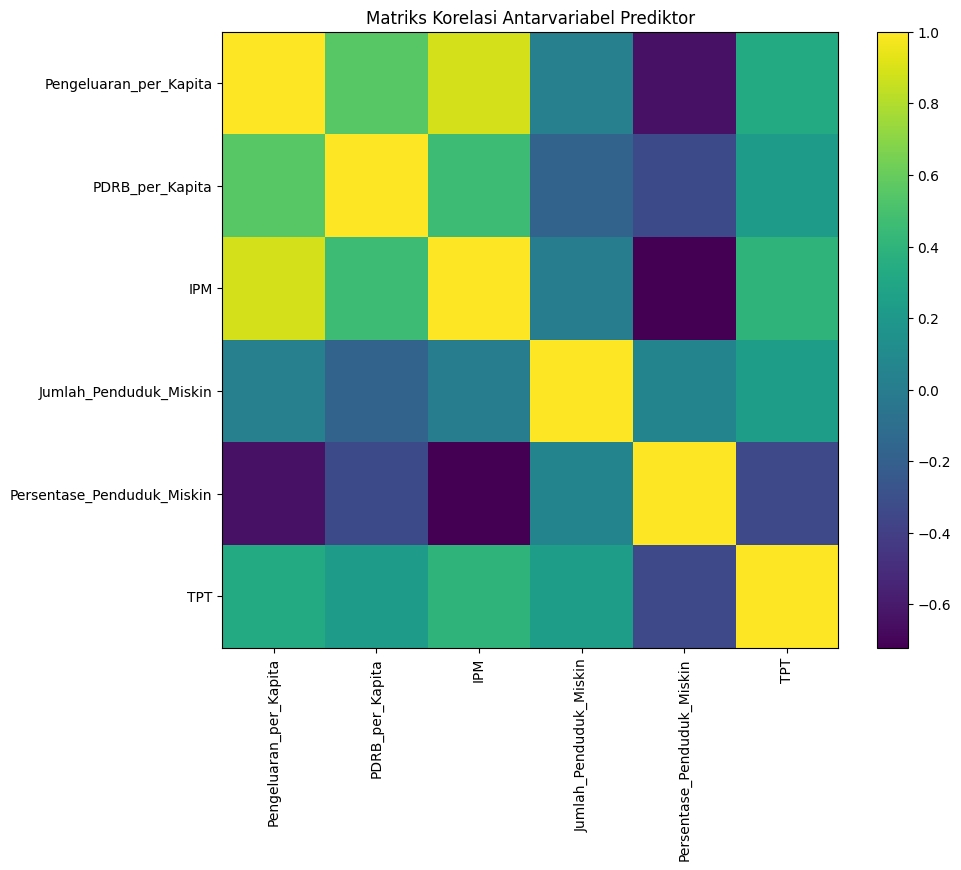

Hasil VIF:


,Variabel,VIF
2,IPM,6.335420
0,Pengeluaran_per_Kapita,5.730962
4,Persentase_Penduduk_Miskin,2.125568
1,PDRB_per_Kapita,1.562079
5,TPT,1.326388
3,Jumlah_Penduduk_Miskin,1.175557


In [42]:
# ============================================================
# 13. KORELASI DAN UJI MULTIKOLINEARITAS VIF
# ============================================================

tahun_tersedia = sorted(data_model["Tahun"].dropna().unique())

max_year = int(max(tahun_tersedia))
prediction_year = max_year + 1

print("Tahun maksimum data X:", max_year)
print("Tahun yang akan diprediksi:", prediction_year)

# Data yang memiliki APS_next dipakai untuk analisis awal
analysis_data = data_provinsi.dropna(subset=["APS_next"]).copy()

corr_matrix = analysis_data[features].corr()

print("Matriks korelasi:")
display(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.colorbar()
plt.title("Matriks Korelasi Antarvariabel Prediktor")
plt.show()


# VIF
X_vif = analysis_data[features].copy()

imputer_vif = SimpleImputer(strategy="median")
X_vif_imputed = imputer_vif.fit_transform(X_vif)

scaler_vif = StandardScaler()
X_vif_scaled = scaler_vif.fit_transform(X_vif_imputed)

vif_result = pd.DataFrame()
vif_result["Variabel"] = features
vif_result["VIF"] = [
    variance_inflation_factor(X_vif_scaled, i)
    for i in range(X_vif_scaled.shape[1])
]

vif_result = vif_result.sort_values("VIF", ascending=False)

print("Hasil VIF:")
display(vif_result)

In [43]:
# ============================================================
# 14. PEMBAGIAN TRAIN, TEST, DAN FUTURE DATA
# ============================================================

max_year = int(data_model["Tahun"].max())
test_year = max_year - 1
future_year = max_year
prediction_year = max_year + 1

print("Tahun data terakhir:", max_year)
print("Tahun testing:", test_year)
print("Tahun input prediksi:", future_year)
print("Tahun APS yang diprediksi:", prediction_year)

train_data = data_model[
    (data_model["Tahun"] < test_year)
].dropna(subset=["APS_next"]).copy()

test_data = data_model[
    (data_model["Tahun"] == test_year)
].dropna(subset=["APS_next"]).copy()

future_data = data_model[
    (data_model["Tahun"] == future_year)
].copy()

X_train = train_data[features]
y_train = train_data["APS_next"]

X_test = test_data[features]
y_test = test_data["APS_next"]

X_future = future_data[features]

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing:", X_test.shape)
print("Jumlah data prediksi future:", X_future.shape)

if len(X_train) == 0:
    raise ValueError("Data training kosong. Periksa data APS dan variabel X.")

if len(X_test) == 0:
    raise ValueError("Data testing kosong. Periksa APS tahun testing.")

if len(X_future) == 0:
    raise ValueError("Data future kosong. Periksa data tahun terakhir.")

Tahun data terakhir: 2025
Tahun testing: 2024
Tahun input prediksi: 2025
Tahun APS yang diprediksi: 2026
Jumlah data training: (136, 6)
Jumlah data testing: (38, 6)
Jumlah data prediksi future: (38, 6)


In [44]:
# ============================================================
# 15. MODELING: LINEAR REGRESSION DAN RANDOM FOREST
# ============================================================

linear_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        max_depth=None
    ))
])

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Model Linear Regression dan Random Forest berhasil dilatih.")

Model Linear Regression dan Random Forest berhasil dilatih.


In [45]:
# ============================================================
# 16. EVALUASI MODEL
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


evaluation_result = pd.DataFrame([
    evaluate_model(linear_model, X_test, y_test, "Regresi Linear"),
    evaluate_model(rf_model, X_test, y_test, "Random Forest Regressor")
])

display(evaluation_result)

best_model_name = evaluation_result.sort_values("MAE").iloc[0]["Model"]

if best_model_name == "Regresi Linear":
    best_model = linear_model
else:
    best_model = rf_model

print("Model terbaik berdasarkan MAE:", best_model_name)

,Model,MAE,RMSE,R2
0,Regresi Linear,3.929504,4.807499,0.543092
1,Random Forest Regressor,3.434873,4.850856,0.534814


Model terbaik berdasarkan MAE: Random Forest Regressor


In [46]:
# ============================================================
# 17. PREDIKSI APS TAHUN BERIKUTNYA MENURUT PROVINSI
# ============================================================

future_data = future_data.copy()

future_data[f"Prediksi_APS_{prediction_year}"] = best_model.predict(X_future)
future_data[f"APS_{future_year}"] = future_data["APS_19_23"]
future_data[f"Selisih_{prediction_year}_terhadap_{future_year}"] = (
    future_data[f"Prediksi_APS_{prediction_year}"] - future_data[f"APS_{future_year}"]
)

hasil_prediksi_provinsi = future_data[
    [
        "Provinsi",
        f"APS_{future_year}",
        f"Prediksi_APS_{prediction_year}",
        f"Selisih_{prediction_year}_terhadap_{future_year}"
    ]
].sort_values("Provinsi")

display(hasil_prediksi_provinsi)

,Provinsi,APS_2025,Prediksi_APS_2026,Selisih_2026_terhadap_2025
5,Aceh,34.95,37.69526,2.74526
11,Bali,34.32,33.44666,-0.87334
17,Banten,24.45,33.03268,8.58268
23,Bengkulu,34.18,35.71396,1.53396
29,DI Yogyakarta,54.72,48.18256,-6.53744
35,DKI Jakarta,34.21,33.08258,-1.12742
41,Gorontalo,35.02,26.67650,-8.34350
47,Jambi,25.23,32.08546,6.85546
53,Jawa Barat,27.98,29.51248,1.53248
59,Jawa Tengah,27.44,30.16716,2.72716


In [48]:
# ============================================================
# 18. PREDIKSI APS NASIONAL TIDAK DIGUNAKAN
# ============================================================
# Penelitian ini hanya berfokus pada prediksi APS menurut provinsi.
# Data nasional/Indonesia tidak digunakan karena variabel PDRB per kapita
# tidak tersedia untuk agregat Indonesia pada dataset yang digunakan.

hasil_prediksi_indonesia = pd.DataFrame()

print("Prediksi nasional tidak digunakan. Analisis hanya dilakukan untuk data provinsi.")

Prediksi nasional tidak digunakan. Analisis hanya dilakukan untuk data provinsi.


In [49]:
# ============================================================
# 19. FEATURE IMPORTANCE DAN KOEFISIEN REGRESI
# ============================================================

# Feature importance Random Forest
rf_regressor = rf_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Variabel": features,
    "Nilai_Kepentingan": rf_regressor.feature_importances_
}).sort_values("Nilai_Kepentingan", ascending=False)

print("Feature Importance Random Forest:")
display(feature_importance)


# Koefisien Regresi Linear
linear_regressor = linear_model.named_steps["model"]

linear_coefficients = pd.DataFrame({
    "Variabel": features,
    "Koefisien_Regresi": linear_regressor.coef_
}).sort_values("Koefisien_Regresi", ascending=False)

print("Koefisien Regresi Linear:")
display(linear_coefficients)

Feature Importance Random Forest:


,Variabel,Nilai_Kepentingan
2,IPM,0.299865
4,Persentase_Penduduk_Miskin,0.225304
3,Jumlah_Penduduk_Miskin,0.164916
5,TPT,0.115296
1,PDRB_per_Kapita,0.100206
0,Pengeluaran_per_Kapita,0.094412


Koefisien Regresi Linear:


,Variabel,Koefisien_Regresi
2,IPM,10.826922
4,Persentase_Penduduk_Miskin,4.731977
1,PDRB_per_Kapita,-0.755567
3,Jumlah_Penduduk_Miskin,-1.207045
5,TPT,-1.209607
0,Pengeluaran_per_Kapita,-5.862159


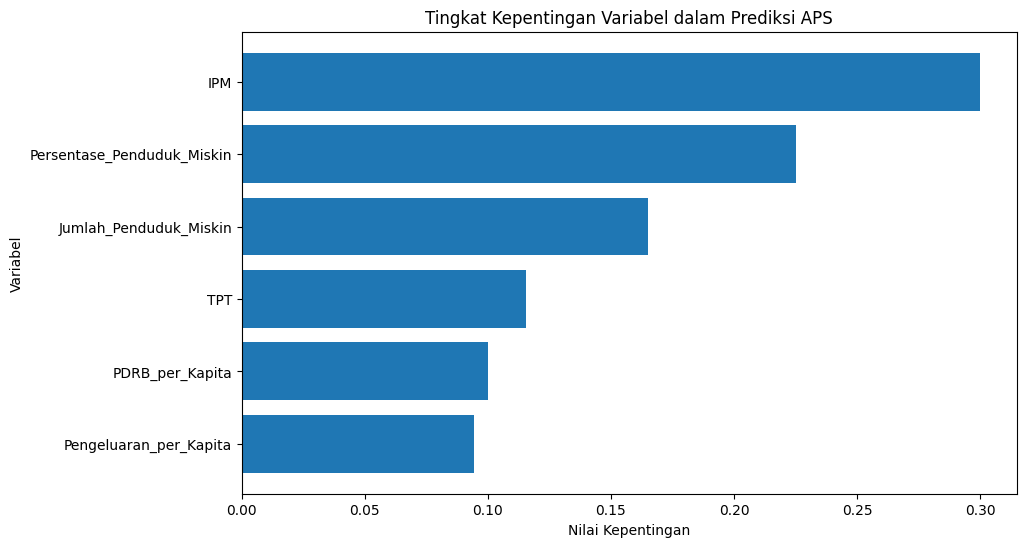

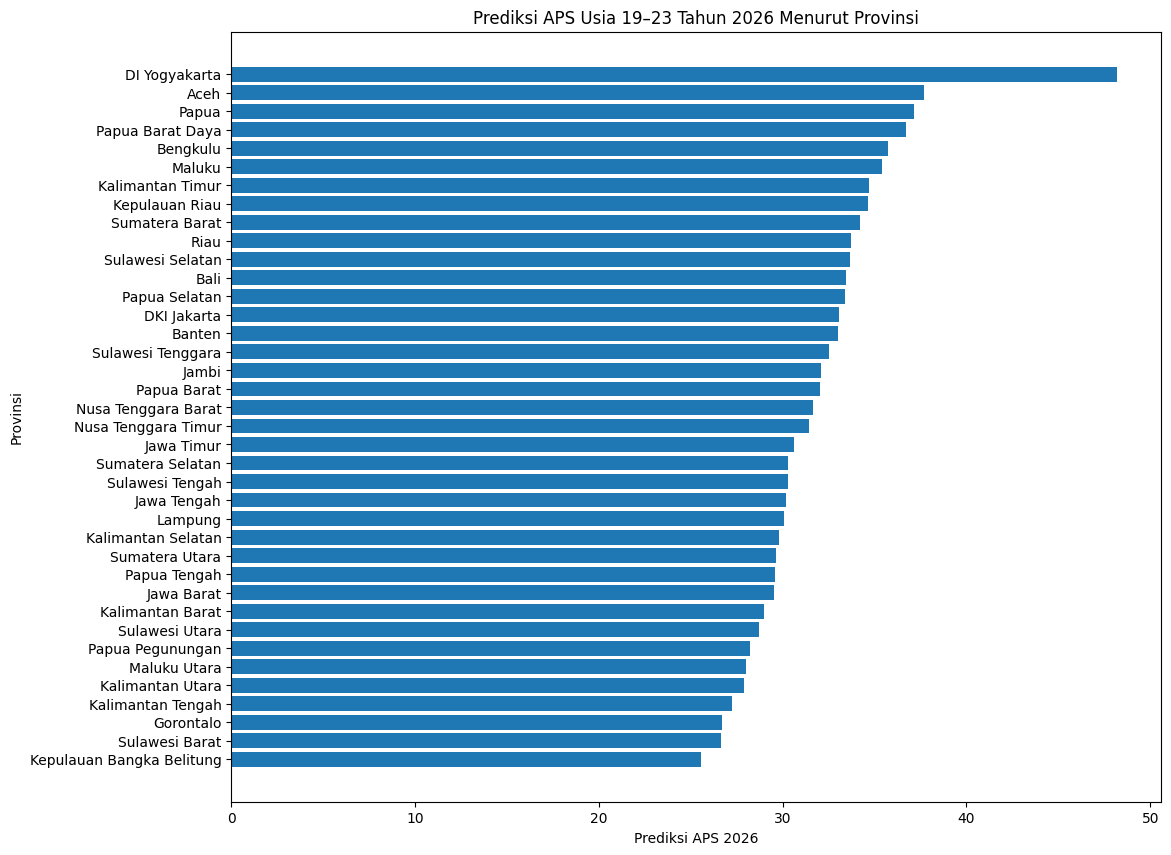

In [50]:
# ============================================================
# 20. VISUALISASI HASIL
# ============================================================

# Visualisasi feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Variabel"], feature_importance["Nilai_Kepentingan"])
plt.xlabel("Nilai Kepentingan")
plt.ylabel("Variabel")
plt.title("Tingkat Kepentingan Variabel dalam Prediksi APS")
plt.gca().invert_yaxis()
plt.show()


# Visualisasi prediksi APS
plot_data = hasil_prediksi_provinsi.sort_values(f"Prediksi_APS_{prediction_year}", ascending=False)

plt.figure(figsize=(12, 10))
plt.barh(plot_data["Provinsi"], plot_data[f"Prediksi_APS_{prediction_year}"])
plt.xlabel(f"Prediksi APS {prediction_year}")
plt.ylabel("Provinsi")
plt.title(f"Prediksi APS Usia 19–23 Tahun {prediction_year} Menurut Provinsi")
plt.gca().invert_yaxis()
plt.show()

In [51]:
# ============================================================
# 21. MENYIMPAN HASIL KE EXCEL
# ============================================================

output_file = f"hasil_prediksi_aps_{prediction_year}_provinsi.xlsx"

with pd.ExcelWriter(output_file) as writer:
    file_inventory.to_excel(writer, sheet_name="Daftar File", index=False)
    data.to_excel(writer, sheet_name="Dataset Gabungan", index=False)
    data_model.to_excel(writer, sheet_name="Dataset Model", index=False)
    missing_report.to_excel(writer, sheet_name="Missing Value", index=False)
    descriptive_stats.to_excel(writer, sheet_name="Statistik Deskriptif")
    corr_matrix.to_excel(writer, sheet_name="Korelasi")
    vif_result.to_excel(writer, sheet_name="VIF", index=False)
    evaluation_result.to_excel(writer, sheet_name="Evaluasi Model", index=False)
    hasil_prediksi_provinsi.to_excel(writer, sheet_name="Prediksi Provinsi", index=False)
    feature_importance.to_excel(writer, sheet_name="Feature Importance", index=False)
    linear_coefficients.to_excel(writer, sheet_name="Koefisien Linear", index=False)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>